# NumerAI Rapid Research Template

In [2]:
import sys
import warnings
from pathlib import Path
import os

import pandas as pd
from sklearn.base import clone

warnings.filterwarnings("ignore")

NOTEBOOK_PATH = Path(
    globals().get("__vsc_ipynb_file__", Path.cwd() / "template.ipynb")
).resolve()
    
REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

from utils.data import (
    align_on_id,
    apply_validation_embargo,
    build_dataset_columns,
    load_benchmark_frame,
    load_feature_set,
    read_parquet_with_id_index,
)
from utils.metrics import calculate_metrics
from utils.postprocessing import build_evaluation_frame, neutralize_by_era, rank_by_era
from utils.visualization import display_metrics_table, plot_metric_over_time

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

In [3]:
DATA_VERSION = "v5.2"
DATA_DIR = "../../data"
TRAIN_PATH = os.path.join(DATA_DIR, DATA_VERSION, "train.parquet")
VALIDATION_PATH = os.path.join(DATA_DIR, DATA_VERSION, "validation.parquet")
VALIDATION_BENCHMARKS_PATH = os.path.join(DATA_DIR, DATA_VERSION, "validation_benchmark_models.parquet")

FEATURE_SET_KEY = ["small"]
CUSTOM_FEATURE_LIST = None
TARGET_COL = "target_ender_20"
BENCHMARK_COL = "v52_lgbm_ender20"
EMBARGO_ERAS = 4

USE_STANDARD_LOADER = True
ALIGN_VALIDATION_BENCHMARKS = True

ENABLE_NEUTRALIZATION = True
NEUTRALIZATION_PROPORTION = 0.25

FORCE_HISTORY_OVERWRITE = True

## 1) Load Data
Use the standard loader for the common case, or switch `USE_STANDARD_LOADER = False` to control paths and columns manually.

In [4]:
_, feature_set = load_feature_set(
    features_path=os.path.join(DATA_DIR, DATA_VERSION, "features.json"),
    feature_set_key=FEATURE_SET_KEY,
    feature_list=CUSTOM_FEATURE_LIST,
)

validation_columns = build_dataset_columns(
    feature_set=feature_set,
    target_cols=TARGET_COL,
)

validation_source = Path(VALIDATION_PATH) if VALIDATION_PATH is not None else Path(DATA_DIR) / DATA_VERSION / "validation.parquet"
benchmark_source = (
    Path(VALIDATION_BENCHMARKS_PATH)
    if VALIDATION_BENCHMARKS_PATH is not None
    else Path(DATA_DIR) / DATA_VERSION / "validation_benchmark_models.parquet"
)

validation = read_parquet_with_id_index(validation_source, columns=validation_columns)

val_benchmarks = load_benchmark_frame(
    benchmark_path=benchmark_source,
    benchmark_columns=[BENCHMARK_COL],
)

if ALIGN_VALIDATION_BENCHMARKS:
    validation, val_benchmarks = align_on_id(validation, val_benchmarks)

print("Loader mode     :", "standard" if USE_STANDARD_LOADER else "custom")
print("Validation shape:", validation.shape)
print("Feature count   :", len(feature_set))
print("Benchmark col   :", BENCHMARK_COL)

print("\nValidation data sample:")
display(validation[["era", TARGET_COL]].head())

Loader mode     : standard
Validation shape: (3943998, 44)
Feature count   : 42
Benchmark col   : v52_lgbm_ender20

Validation data sample:


,era,target_ender_20
id,,
n000101811a8a843,0575,0.5
n001e1318d5072ac,0575,0.5
n002a9c5ab785cbb,0575,0.5
n002ccf6d0e8c5ad,0575,0.0
n0041544c345c91d,0575,0.5


## 2) Train Model

In [5]:
validation_model_frame = validation.dropna(subset=[TARGET_COL]).copy()

# Distribution of target values in the validation set
print("\nTarget distribution in validation set:")
display(validation_model_frame[TARGET_COL].value_counts())


Target distribution in validation set:


target_ender_20
0.50    1954442
0.75     781768
0.25     781139
0.00     196077
1.00     195448
Name: count, dtype: int64

In [6]:
validation_model_frame = validation.dropna(subset=[TARGET_COL]).copy()

# Model

# Constant prediction using mean or median
# _mean = validation_model_frame[TARGET_COL].mean() # MMC -0.00022
# _median = validation_model_frame[TARGET_COL].median() # MMC -0.00022
#constant_validation_predictions = pd.Series(_median, index=validation_model_frame.index)
#---------------

# The previous value for each era
# Pad the first value with the mean of the target to avoid NaN values
# constant_validation_predictions = validation_model_frame.groupby("era")[TARGET_COL].shift(1)
# constant_validation_predictions = constant_validation_predictions.fillna(validation_model_frame[TARGET_COL].mean())

#----------
# The average of the 5 previous values for each era
constant_validation_predictions = validation_model_frame.groupby("era")[TARGET_COL].transform(lambda x: x.shift(1).rolling(window=5, min_periods=1).mean())
constant_validation_predictions = constant_validation_predictions.fillna(validation_model_frame[TARGET_COL].mean())



print("Validation rows used :", len(validation_model_frame))
print("Raw prediction range :", (constant_validation_predictions.min(), constant_validation_predictions.max()))

Validation rows used : 3908874
Raw prediction range : (np.float64(0.0), np.float64(1.0))


## 3) Optional Neutralization

In [7]:
print("Neutralization enabled:", ENABLE_NEUTRALIZATION)
ENABLE_NEUTRALIZATION = False

if ENABLE_NEUTRALIZATION:
    final_validation_predictions = neutralize_by_era(
        predictions=constant_validation_predictions,
        eras=validation_model_frame["era"],
        features=validation_model_frame[feature_set],
        proportion=NEUTRALIZATION_PROPORTION,
        rank_output=True,
    )
else:
    final_validation_predictions = rank_by_era(
        predictions=constant_validation_predictions,
        eras=validation_model_frame["era"],
    )

print(
    "Final prediction range:",
    (final_validation_predictions.min(), final_validation_predictions.max()),
)

Neutralization enabled: True
Final prediction range: (np.float64(0.00013681762210972773), np.float64(1.0))


## 4) Evaluate

In [8]:
evaluation_frame = build_evaluation_frame(
    validation=validation_model_frame,
    predictions=final_validation_predictions,
    target_col=TARGET_COL,
)

                             KEY PERFORMANCE METRICS vs GOALS                             


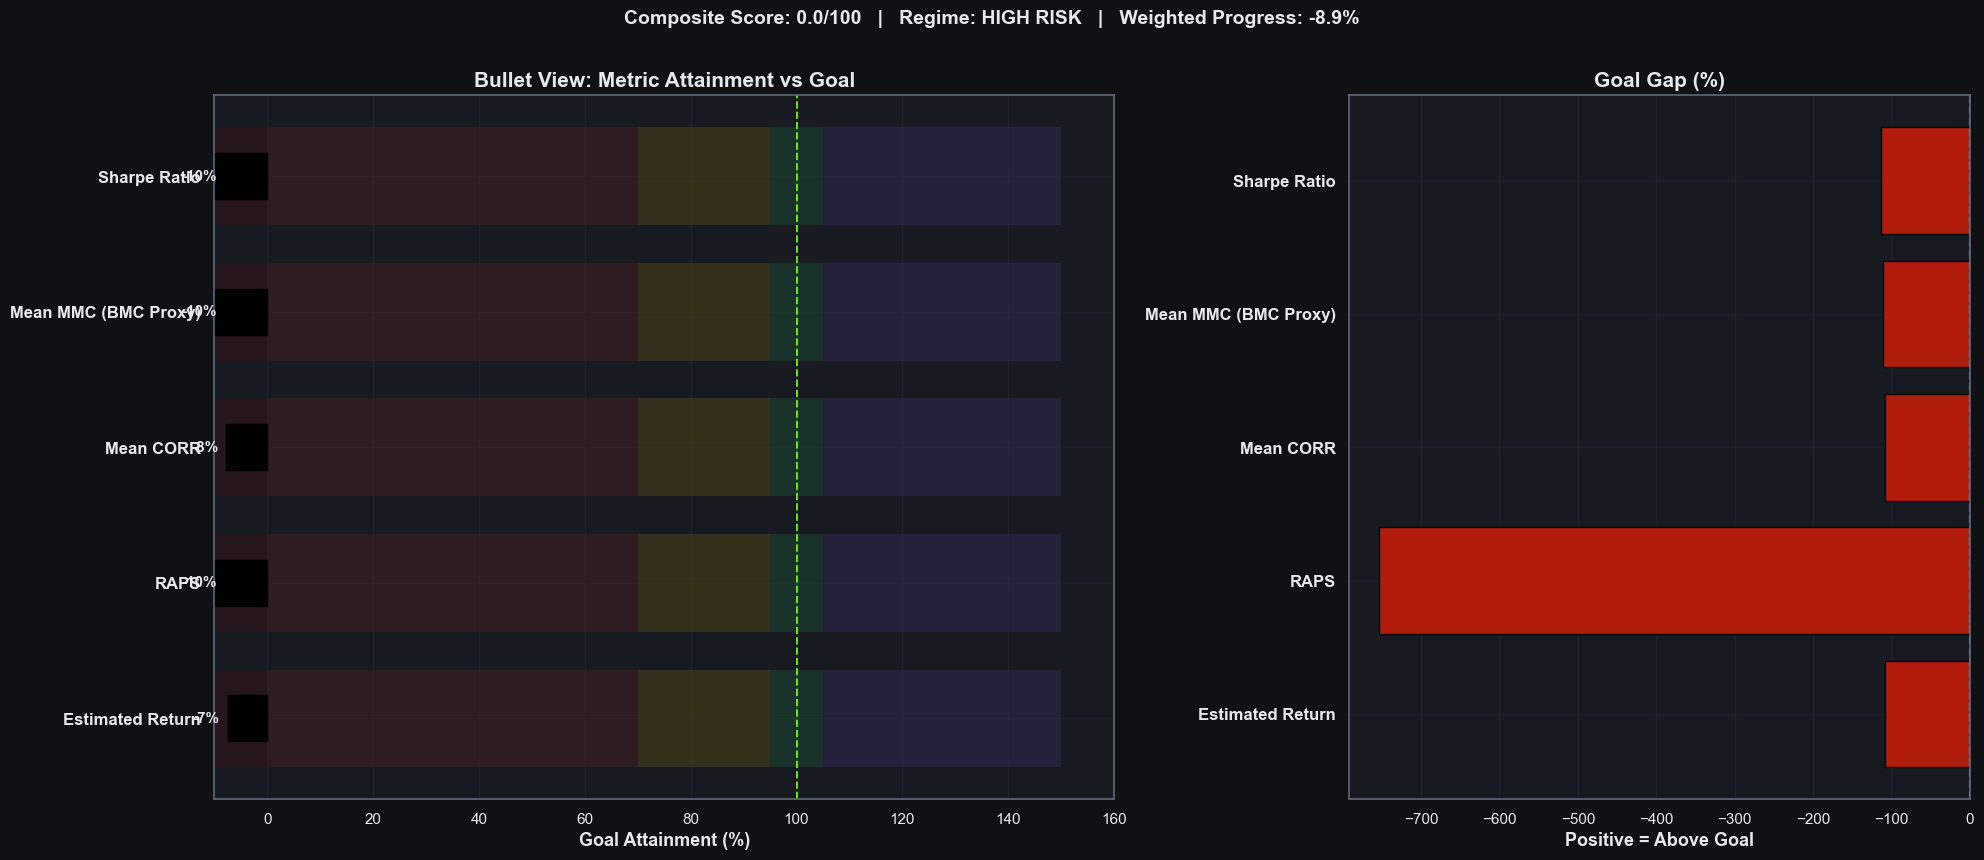

Category,Metric,Value,Goal,Gap %,Progress %,Status,Interpretation
Payout,Estimated Return,-1.87%,+25.00%,-107.5%,-7.5%,🔴 BELOW,"Approximate payout percent using 0.75× CORR + 2.25× MMC, capped at +/-5%"
Payout,RAPS,-0.6540,+0.1000,-754.0%,-10.0%,🔴 BELOW,Risk-adjusted payout proxy with drawdown and tail-risk penalties
Payout,Mean MMC (BMC Proxy),-0.00103,+0.01000,-110.3%,-10.0%,🔴 BELOW,Uniqueness vs benchmark with the current 2.25× payout weight proxy
Payout,Mean CORR,-0.00170,+0.02200,-107.7%,-7.7%,🔴 BELOW,Official Numerai correlation score; strong models are often 0.01-0.03
Quality,Win Rate,44.0%,85.0%,-48.2%,51.8%,🟠 LAGGING,Fraction of eras with positive CORR
Quality,Mean FNC,—,+0.01000,—,—,—,CORR after removing linear feature exposure
Risk,Max Drawdown,-1.16840,-0.10000,-1068.4%,-10.0%,🔴 BELOW,Worst sustained CORR cumulative loss
Risk,Sharpe Ratio,-0.1353,+1.0000,-113.5%,-10.0%,🔴 BELOW,Risk-adjusted return consistency
Risk,Payout Sharpe,-0.1044,+1.2500,-108.4%,-8.4%,🔴 BELOW,Sharpe ratio of payout proxy (0.75× CORR + 2.25× MMC)
Risk,MMC Volatility,+0.01118,—,—,—,—,Standard deviation of era-by-era MMC


In [9]:
metrics, per_era_df = calculate_metrics(
    df_validation=evaluation_frame,
    benchmarks=val_benchmarks,
    features=feature_set,
    target_col=TARGET_COL,
    benchmark_col=BENCHMARK_COL,
    fast_metrics=True,
)

display_metrics_table(metrics, extended=True)

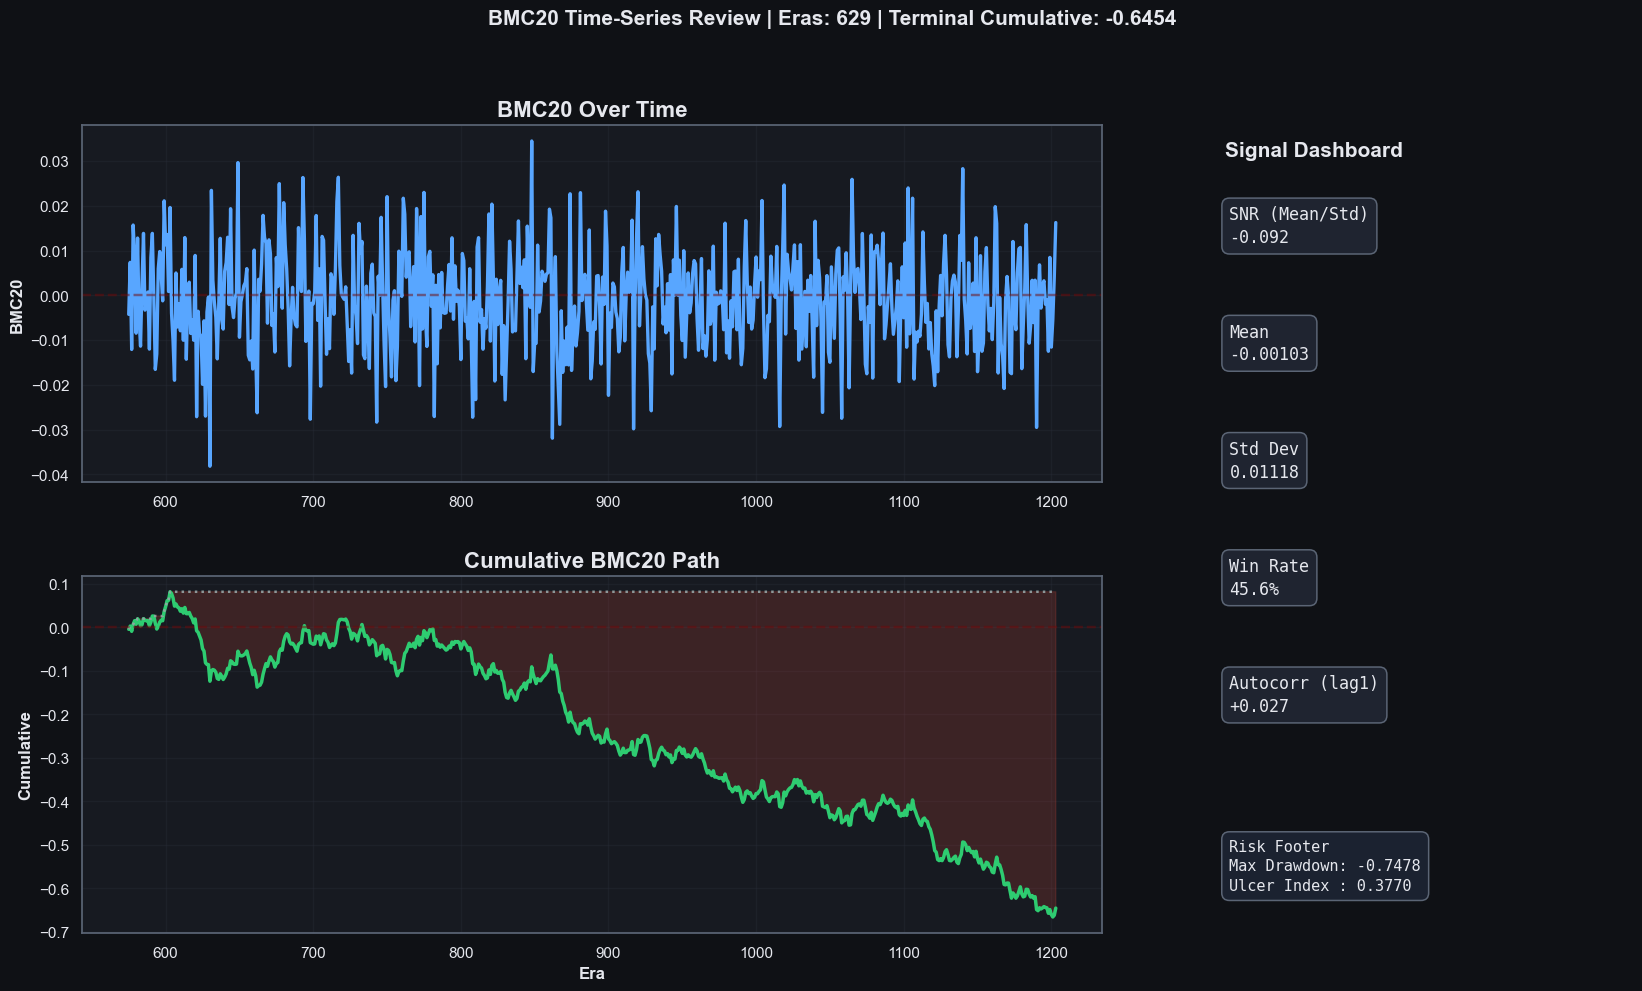

In [10]:
plot_metric_over_time(
        per_era_df=per_era_df,
        metric="BMC20",
    )

In [11]:
from utils.model_benchmark import compare_top_models_with_current, record_model_metrics


history_df, record = record_model_metrics(
    metrics=metrics,
    model_name="average_of_past_5_targets",
    notebook_name=NOTEBOOK_PATH.name,
    force=FORCE_HISTORY_OVERWRITE,
)
display(pd.DataFrame([record]))

leaderboard, is_top_model = compare_top_models_with_current(
    current_run_id=record["run_id"],
    top_n=5,
    show_message=True,
)

,run_id,model_name,9_Annualized_Return_PCT,4_Mean_BMC20,3_Mean_CORR20V2,1_RAPS,5_Sharpe_CORR,2_Sharpe_Payout,7_Max_Drawdown_CORR,8_Win_Rate,6_Mean_FNC,10_Benchmark_Corr,11_BMC_Volatility,4_Mean_MMC20,11_MMC_Volatility,notebook_name,timestamp_utc,history_path,status,message
0,7035f2a8,average_of_past_5_targets,-1.8749,-0.001026,-0.001696,-0.65403,-0.13531,-0.10445,-1.1684,0.44038,NaN,0.000663,0.011178,-0.001026,0.011178,average_past_n_targets.ipynb,2026-03-29 18:19:36,C:\dev\numer-AI\submissions\model_metrics_hist...,inserted,Inserted new model metrics.


rank,run id,model name,Annualized Return PCT,Mean BMC20,Mean CORR20V2,RAPS,Sharpe CORR,Sharpe Payout,Max Drawdown CORR,Win Rate,Mean FNC,Benchmark Corr,BMC Volatility,MMC Volatility,timestamp utc
#1,7d85f24f,ridge_baseline_templateTOP 1,+3.6996%,-0.00038894,+0.010567,-0.26594,+0.7651,+0.2014,-0.158,+0.7744,-,+0.32543,+0.011406,+0.011406,2026-03-29 18:15:25
#2,77573be0,const_val_validation_meanTOP 2,-0.42082%,-0.00021524,-0.00036118,-0.26866,-0.029267,-0.02261,-0.41185,+0.4849,-,-0.00020131,+0.010843,+0.010843,2026-03-29 18:16:40
#3,7035f2a8,average_of_past_5_targetsTOP 3CURRENT RUN,-1.8749%,-0.001026,-0.0016959,-0.65403,-0.13531,-0.10445,-1.1684,+0.44038,-,+0.00066332,+0.011178,+0.011178,2026-03-29 18:19:36


## 5) Breakpoint

In [12]:
assert False, "Inspect metrics and per-era results before retraining on full data."

AssertionError: Inspect metrics and per-era results before retraining on full data.

## 6) Optional Retrain On Full Data

In [ ]:
if not RETRAIN_ON_FULL_DATA:
    print("Set RETRAIN_ON_FULL_DATA = True after removing or bypassing the breakpoint.")
else:
    full_training_frame = pd.concat([train, validation], axis=0)
    full_training_frame = full_training_frame.dropna(subset=[TARGET_COL]).copy()

    final_model = clone(ESTIMATOR)
    final_model.fit(full_training_frame[feature_set], full_training_frame[TARGET_COL])

    print(final_model)
    print("Full-data rows used:", len(full_training_frame))